# Supplementary Figure S39: zebrafish attention and control comparisons

Compare zebrafish attention scores with COMMOT and examine JAM-positive spatial neighbors. Recalculate the comparisons used in S39.


## Before you start

Follow the [source installation](../../installation.md), then run these cells in order. The numerical inputs are included with the code. The notebook saves new figures and their calculation tables.

To generate these inputs from fitted models, see the [calculation guide](../../reference/figure_sources/zebrafish-attention.md).


## Load figure inputs


In [1]:
import os
import pandas as pd

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

from pathlib import Path

from IPython.display import Image, display

from CytoBridge.results.zebrafish_attention import load_zebrafish_attention_results, write_zebrafish_attention_tables, zebrafish_attention_statistics

output_dir = Path(os.environ.get("CYTOBRIDGE_PROJECT_DIR", ".")) / "outputs" / "zebrafish_attention"
output_dir.mkdir(parents=True, exist_ok=True)
results = load_zebrafish_attention_results()
{
    "panel_data_files": len(results.manifest["files"]),
    "directed_pair_rows": len(results.directed_pair_concordance),
    "spatial_cells": len(results.spatial_cells),
}


{'panel_data_files': 10, 'directed_pair_rows': 4, 'spatial_cells': 3048}

## Recalculate panel values


In [2]:
statistics = zebrafish_attention_statistics(results)
display(results.panels.external_agreement)
display(results.panels.jam_quartiles)
display(results.panels.spatial_null)
statistics


,cytobridge_view,external_method,n_pairs,n_strata,n_permutations,adjusted_spearman_rho,null_adjusted_spearman_mean,null_adjusted_spearman_q025,null_adjusted_spearman_q975,adjusted_spearman_empirical_p_upper
0,attention,COMMOT,361,22,1000,0.886077,0.705128,0.661242,0.751226,0.000999
1,attention,CellAgentChat,361,22,1000,0.221125,0.163284,0.130932,0.197256,0.000999


,condition,top_n_edges_after_boundary_ties,top_n_jam_compatible,top_n_non_compatible,top_compatibility_rate,bottom_n_edges_after_boundary_ties,bottom_n_jam_compatible,bottom_n_non_compatible,bottom_compatibility_rate,top_vs_bottom_odds_ratio,fisher_exact_two_sided_p,top_compatibility_percent,bottom_compatibility_percent
0,trained,170,44,126,0.258824,170,3,167,0.017647,19.439153,1.482602e-11,25.882353,1.764706
1,pre_interaction,170,15,155,0.088235,170,12,158,0.070588,1.274194,6.889985e-01,8.823529,7.058824
2,random,170,17,153,0.100000,170,17,153,0.100000,1.000000,1.000000e+00,10.000000,10.000000


,n_permutations,observed_neighbor_pairs,null_mean,null_q025,null_q975,observed_over_null_mean,n_null_at_least_observed,plus_one_upper_tail_p
0,10000,396,286.2387,247.0,329.0,1.383461,0,0.0001


{'conditions': ['trained', 'pre_interaction', 'random'],
 'directed_cell_type_pairs': 361,
 'somite_cells': 375,
 'directed_edges_per_condition': 677,
 'display_edges': 15,
 'spatial_null_permutations': 10000,
 'observed_neighbor_pairs': 396,
 'spatial_null_mean': 286.2387,
 'spatial_fold': 1.3834607270086121,
 'spatial_plus_one_p': 9.999000099990002e-05,
 'commot_adjusted_spearman': 0.8860773232072998,
 'cellagentchat_adjusted_spearman': 0.22112511247107317}

## Draw and save the figure


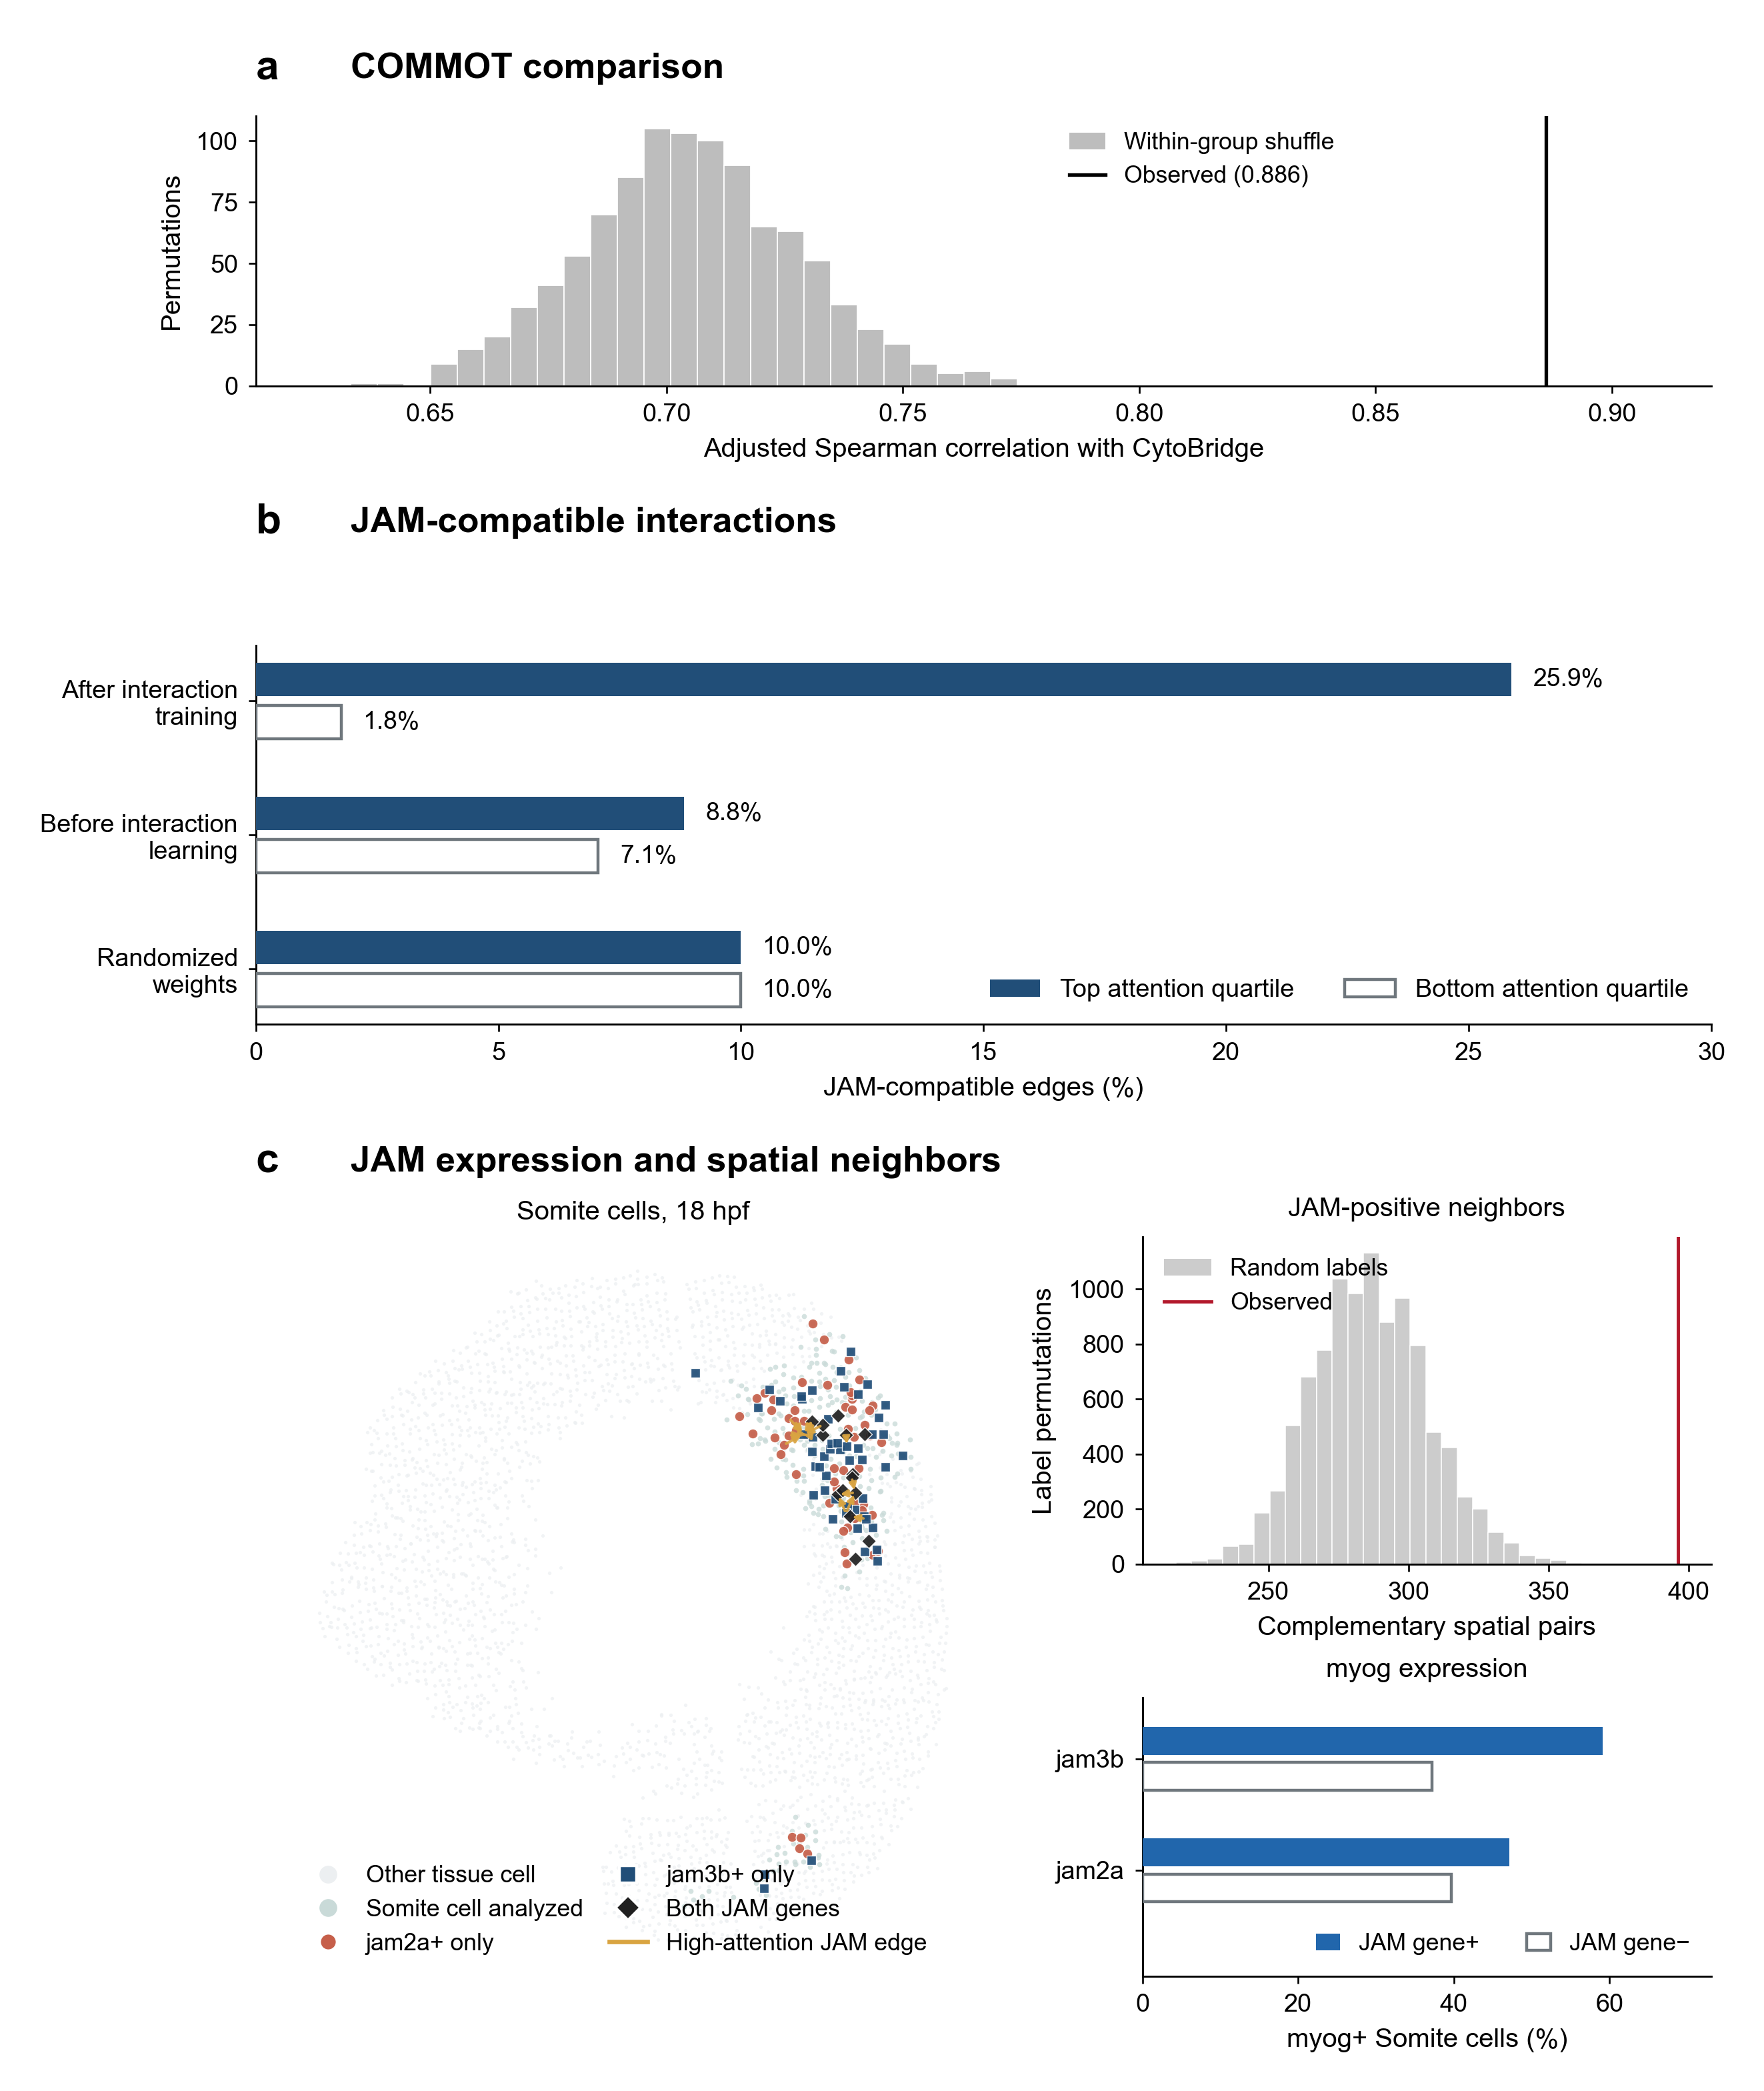

{'tables': {'external_agreement': True,
  'jam_quartiles': True,
  'somite_ranks': True,
  'myog_detection': True,
  'spatial_null': True},
 'pdf': True,
 'png': True}

In [3]:
table_paths = write_zebrafish_attention_tables(results, output_dir)
from reproduction.paper_figures import draw_supplementary
pdf_path, png_path = draw_supplementary([39], output_dir)["s39"]
display(Image(filename=str(png_path), width=700))
{
    "tables": {name: path.is_file() for name, path in table_paths.items()},
    "pdf": pdf_path.is_file(),
    "png": png_path.is_file(),
}